# Exercise 04 — Plotting and Functions (Training Assignment)

NUMA01 VT2026 — Arvid Brenner & Sixten Midsem

Lösningar till `exercise04.md`. Plotting med matplotlib, komplexa funktioner,
Newtons metod.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Task 1 — Cirkel via cos/sin

`(cos x, sin x)` för $x \in [0, 2\pi]$ ritar enhetscirkeln. Vi lägger till
`axis('equal')` så att den ser cirkulär ut.


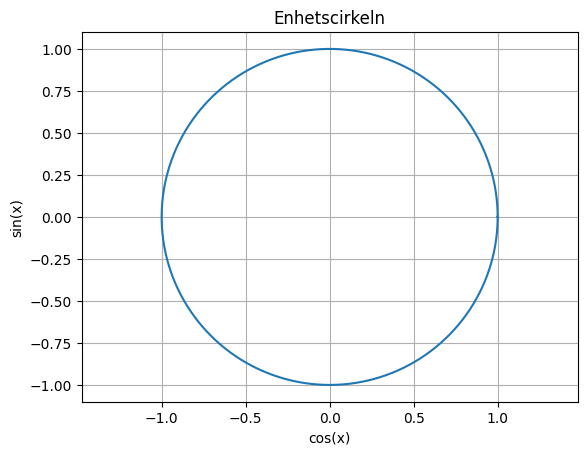

In [2]:
x = np.linspace(0, 2 * np.pi, 1000)
plt.figure()
plt.plot(np.cos(x), np.sin(x))
plt.xlabel('cos(x)'); plt.ylabel('sin(x)')
plt.axis('equal'); plt.grid(True)
plt.title('Enhetscirkeln')
plt.show()


## Task 2 — Stilformatering och legend

Se kapitel 6, *Formatting*. Här ett exempel med olika linjestilar, markörer
och legend.


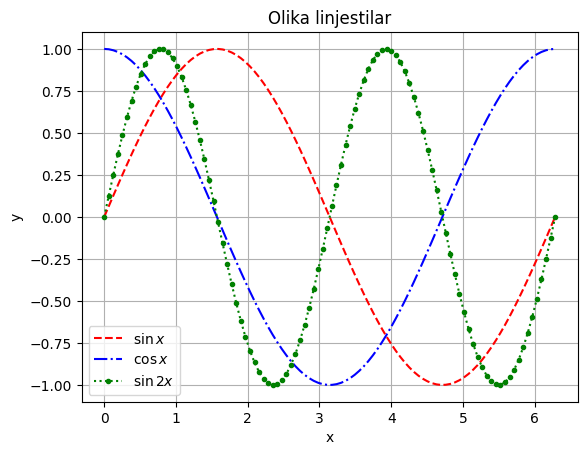

In [3]:
x = np.linspace(0, 2 * np.pi, 100)
plt.figure()
plt.plot(x, np.sin(x),  'r--',  label=r'$\sin x$')
plt.plot(x, np.cos(x),  'b-.',  label=r'$\cos x$')
plt.plot(x, np.sin(2*x), 'g:o', markersize=3, label=r'$\sin 2x$')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True)
plt.title('Olika linjestilar')
plt.show()


## Task 3 — Komplexa cirklar

$f(\varphi, r) = r e^{i\varphi}$ — fixt $r$ ger en cirkel med radie $r$.
Vi varierar $r$ från 0.1 till 1.0 i steg om 0.1 och ritar koncentriska
cirklar i komplexa planet.


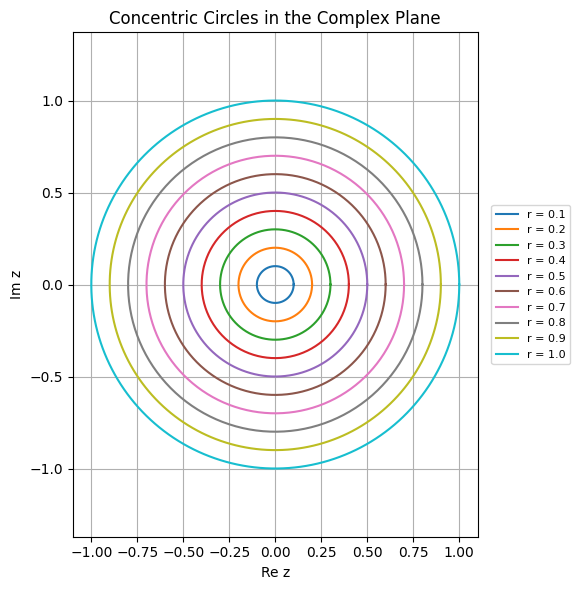

In [4]:
def circle(phi, r):
    """f(phi, r) = r * exp(i*phi)."""
    return r * np.exp(1j * phi)


phi = np.linspace(0, 2 * np.pi, 400)

plt.figure(figsize=(6, 6))
for r in np.arange(0.1, 1.01, 0.1):
    z = circle(phi, r)
    plt.plot(z.real, z.imag, label=f'r = {r:.1f}')

plt.xlabel('Re z'); plt.ylabel('Im z')
plt.title('Concentric Circles in the Complex Plane')
plt.axis('equal'); plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


## Task 4 — Eulers formel

$e^{i\varphi} = \cos\varphi + i\sin\varphi$ — så Task 1 (cos/sin-cirkeln)
och Task 3 (komplex exponential) ritar **samma** kurva för $r=1$.
Realdelen är cosinus, imaginärdelen är sinus.


In [5]:
phi = np.linspace(0, 2 * np.pi, 400)
z = np.exp(1j * phi)
print("max |Re(e^(i phi)) - cos(phi)| =", np.max(np.abs(z.real - np.cos(phi))))
print("max |Im(e^(i phi)) - sin(phi)| =", np.max(np.abs(z.imag - np.sin(phi))))


max |Re(e^(i phi)) - cos(phi)| = 0.0
max |Im(e^(i phi)) - sin(phi)| = 0.0


## Task 5 — Newtons metod

$$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

Avbryter när $|x_{n+1} - x_n| < \text{Tol}$ eller efter 400 iterationer.
Returnerar slutvärdet och en konvergensflagga.


In [6]:
def newton(f, fp, x_0, Tol=1e-10, max_iter=400):
    """Newtons metod. Returnerar (x, conv) — conv=True om |x_{n+1}-x_n|<Tol."""
    x = x_0
    for _ in range(max_iter):
        x_new = x - f(x) / fp(x)
        if abs(x_new - x) < Tol:
            return x_new, True
        x = x_new
    return x, False


# Testfunktion: f(x) = x^2 - 2 ⇒ rot sqrt(2)
def myfunc(x):  return x ** 2 - 2
def myfuncp(x): return 2 * x

root, conv = newton(myfunc, myfuncp, 1.0)
print(f"x^2 - 2:    rot ≈ {root:.12f}  (sant {np.sqrt(2):.12f}, conv={conv})")

# Test: f(x) = cos(x) - x ⇒ rot ≈ 0.7390851332
def g(x):  return np.cos(x) - x
def gp(x): return -np.sin(x) - 1

root2, conv2 = newton(g, gp, 0.5)
print(f"cos(x)-x:   rot ≈ {root2:.12f}  (conv={conv2})")


x^2 - 2:    rot ≈ 1.414213562373  (sant 1.414213562373, conv=True)
cos(x)-x:   rot ≈ 0.739085133215  (conv=True)


## Extra Task 6 — Bisektion vs Newton, konvergens

Vi sparar $|x_{n+1} - x_n|$ för varje iteration och plottar på log-skala.
Newton är **kvadratiskt** konvergent (lutning fördubblas per iteration på
log-skala), bisektion är **linjär** (halveringen → konstant lutning).


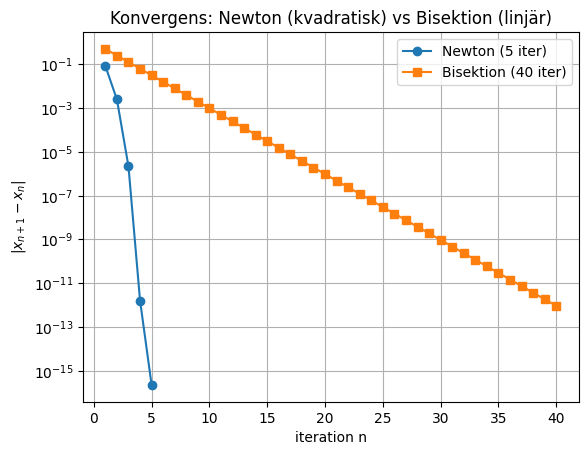

Newton:    5 iterationer till tol 1e-12
Bisektion: 40 iterationer till tol 1e-12


In [7]:
def newton_track(f, fp, x_0, Tol=1e-12, max_iter=400):
    diffs = []
    x = x_0
    for _ in range(max_iter):
        x_new = x - f(x) / fp(x)
        diffs.append(abs(x_new - x))
        if abs(x_new - x) < Tol:
            return x_new, diffs
        x = x_new
    return x, diffs


def bisect_track(f, a, b, Tol=1e-12, max_iter=400):
    diffs = []
    for _ in range(max_iter):
        m = (a + b) / 2
        if f(a) * f(m) < 0:
            b_new = m; a_new = a
        else:
            a_new = m; b_new = b
        diffs.append(abs(b_new - a_new))
        a, b = a_new, b_new
        if b - a < Tol:
            break
    return (a + b) / 2, diffs


# Söker sqrt(2) som rot till x^2 - 2
_, dN = newton_track(myfunc, myfuncp, 1.5, Tol=1e-12)
_, dB = bisect_track(myfunc, 1.0, 2.0, Tol=1e-12)

plt.figure()
plt.semilogy(range(1, len(dN)+1), dN, 'o-', label=f'Newton ({len(dN)} iter)')
plt.semilogy(range(1, len(dB)+1), dB, 's-', label=f'Bisektion ({len(dB)} iter)')
plt.xlabel('iteration n'); plt.ylabel(r'$|x_{n+1}-x_n|$')
plt.title('Konvergens: Newton (kvadratisk) vs Bisektion (linjär)')
plt.legend(); plt.grid(True, which='both'); plt.show()

print(f"Newton:    {len(dN)} iterationer till tol 1e-12")
print(f"Bisektion: {len(dB)} iterationer till tol 1e-12")
